In [118]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [119]:
df = pd.read_csv("../data/mesures_capteurs.csv")
print(df)

    id_mesure           date_heure id_capteur batiment  temperature  humidite  \
0       M0413  2026-01-22 04:00:00       C005     B002        25.46     58.06   
1       M0290  2026-01-17 01:00:00       C002     B001        24.00     79.73   
2       M0077  2026-01-08 04:00:00       C005     B002        25.82     54.47   
3       M0079  2026-01-08 06:00:00       C007     B003        28.23     69.39   
4       M0183  2026-01-12 14:00:00       C003     B001        20.58     53.80   
..        ...                  ...        ...      ...          ...       ...   
600     M0072  2026-01-07 23:00:00       C012     B004        23.67     60.28   
601     M0107  2026-01-09 10:00:00       C011     B004        24.34     61.42   
602     M0271  2026-01-16 06:00:00       C007     B003        23.73     63.49   
603     M0436  2026-01-23 03:00:00       C004     B002        24.83     79.77   
604     M0103  2026-01-09 06:00:00       C007     B003        17.02     52.04   

     pression  consommation

### Partie 1 – Gestion des doublons 

##### 1) vérifier l’existence de doublons dans df

In [120]:
df[df.duplicated()]

,id_mesure,date_heure,id_capteur,batiment,temperature,humidite,pression,consommation,etat
183,M0599,2026-01-29 22:00:00,C011,B004,22.02,68.09,1005.90,227.81,OK
231,M0026,2026-01-06 01:00:00,C002,B001,22.87,77.99,1010.15,213.19,OK
355,M0147,2026-01-11 02:00:00,C003,B001,26.14,84.97,1003.59,142.31,OK
538,M0456,2026-01-23 23:00:00,C012,B004,20.68,72.69,1022.77,309.01,OK
539,M0302,2026-01-17 13:00:00,C002,B001,22.05,58.26,1007.30,140.42,OK


##### 2) le cas échéant, supprimer les doublons puis vérifier la suppression 

In [126]:
df = df.drop_duplicates()

In [127]:
df[df.duplicated()]


,id_mesure,date_heure,id_capteur,batiment,temperature,humidite,pression,consommation,etat


In [130]:
df = df.dropna(subset=["etat"]).reset_index(drop="true")

### Partie 2 – Sélection de y (cible) et X (caractéristiques) 

In [133]:
y = df["etat"]
X = df[["temperature", "humidite", "pression", "consommation"]]

In [131]:
print("Les 5 premières lignes de X :")
print(X.head())

Les 5 premières lignes de X :
   temperature  humidite  pression  consommation
0        25.46     58.06   1008.95        287.28
1        24.00     79.73    993.39        116.20
2        25.82     54.47   1010.32        288.50
3        28.23     69.39   1019.62        136.65
4        20.58     53.80   1016.58        182.62


Dans notre contexte , on a un probleme de classification.

In [132]:
print("Les 5 premières lignes de y :")
print(y.head())

Les 5 premières lignes de y :
0    OK
1    OK
2    OK
3    OK
4    OK
Name: etat, dtype: str


##### 3) Quel est le type du problème de machine learning ? 

le type de probleme de machine learning qu'on a est le probleme de la classification

### Partie 3 – Découpage Train/Test 

In [134]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% des données pour le test
    random_state=42,    # permet de garantir la reproductibilité du découpage
    stratify=y          # permet de conserver les mêmes proportions de classes qu'à l'origine
)

### Partie 4 – Gestion des valeurs manquantes 

##### 1) Vérifier l’existence de valeurs manquantes 

In [136]:
print("les valeurs manquantes dans X_train :")
print(X_train.isnull().sum())

print("\nles valeurs manquantes dans X_test :")
print(X_test.isnull().sum())

les valeurs manquantes dans X_train :
temperature     5
humidite        4
pression        5
consommation    3
dtype: int64

les valeurs manquantes dans X_test :
temperature     1
humidite        1
pression        0
consommation    2
dtype: int64


### 2) Sélectionner SimpleImputer avec la médiane

In [137]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

### 3) Qu’est ce qui justifie le choix de la médiane ? 

la médiane offre une estimation plus robuste et fiable du centre des données lorsque celles-ci peuvent contenir du bruit ou des valeurs extrêmes . ce qui est fréquent avec des données de capteurs IoT.

##### 4) Trouver les paramètres (médianes) de l’imputeur sur X_train

In [138]:
imputer.fit(X_train)

print("Médianes calculées par colonne :")
print(imputer.statistics_)

Médianes calculées par colonne :
[  24.9    65.38 1012.3   206.59]


##### 5) Déterminer X_train_imputed et X_test_imputed, les transformés de X_train et X_test

In [139]:
X_train_imputed = imputer.transform(X_train)
X_test_imputed = imputer.transform(X_test)

### Partie 5 – Mise à l'échelle

##### 1) Sélectionner StandardScaler pour mettre à l’échelle les transformés de l’imputation 

In [140]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

##### 2) Qu’est ce qui justifie la standardisation ? 

Ce qui justifie la standardisation c'est par exemple :
Échelles différentes entre variables : température, humidité, pression et consommation n'ont pas les mêmes unités ni les mêmes ordres de grandeur (par exemple la pression peut varier entre 950-1050 hPa, alors que l'humidité varie entre 0-100%). Sans mise à l'échelle, les variables avec de grandes valeurs numériques domineraient artificiellement les autres dans le modèle.

##### 3) Trouver les paramètres (moyennes et écart-types) du scaleur sur X_train_imputed

In [146]:
scaler.fit(X_train_imputed)

print("Moyennes calculées par colonne :")
print(scaler.mean_.round(2))

print("\nÉcart-types calculés par colonne :")
print(scaler.scale_.round(2))

Moyennes calculées par colonne :
[  24.96   64.85 1012.08  210.15]

Écart-types calculés par colonne :
[ 4.19 10.16 10.99 73.42]


##### 4) Déterminer X_train_scaled et X_test_scaled, les transformés de X_train_imputed et X_test_imputed

In [147]:
X_train_scaled = scaler.transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

### Partie 6 – Entrainement et prédiction d’un modèle 

##### 1) Sélectionner le modèle KNN (k plus proches voisins) avec 5, le nombre de voisins à prendre en compte 

In [148]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

##### 2) Entrainer le modèle 

In [149]:
knn.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[object](3,)","['ALERTE','ERREUR','OK']"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


##### 3) Déterminer y_pred, la prédiction du modèle avec l’ensemble de test 

In [150]:
y_pred = knn.predict(X_test_scaled)

##### 4) Afficher quelques prédictions 

In [152]:
print(" voici quelques prédictions du modèle :")
print(y_pred[:10])

 voici quelques prédictions du modèle :
['OK' 'OK' 'OK' 'OK' 'OK' 'OK' 'OK' 'OK' 'OK' 'OK']


##### 5) Comparer ces prédictions avec les vraies valeurs 

In [153]:
comparaison = pd.DataFrame({
    "Valeur réelle": y_test.values,
    "Prédiction": y_pred
})
print(comparaison.head(10))

  Valeur réelle Prédiction
0            OK         OK
1            OK         OK
2            OK         OK
3            OK         OK
4        ALERTE         OK
5            OK         OK
6            OK         OK
7            OK         OK
8            OK         OK
9            OK         OK


*** explication*** : apres comparaison , nous observons que pour certain valeur reelle , le modele a bien fait la prediction sauf sur l'eta ALERTE le modele s'est trompe il a predit OK au lieu de ALERTE.

### Partie 7 – Evaluation du modèle 

##### 1) Evaluer le modèle avec Accuracy puis afficher le résultat 

In [155]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy du modèle : {accuracy:.2%}")

Accuracy du modèle : 95.83%


##### 2) Pourquoi Accuracy ne suffit pas toujours pour évaluer ? 

L'accuracy ne suffit pas parce qu'elle peut être trompeuse en cas de classes déséquilibrées, et parce qu'elle ne distingue pas les types d'erreurs (faux positifs vs faux négatifs), alors que dans la réalité ces erreurs n'ont souvent pas le même coût.
on peut prendre notre exemple : ici on 95% de nos données sont "normal", un modèle qui prédit toujours "normal" aura 95% d'accuracy tout en étant inutile .il ne détecte jamais les cas "anormal", qui sont pourtant les plus importants à repérer.

##### 3) Déterminer, afficher et commenter la matrice de confusion 

In [158]:
from sklearn.metrics import confusion_matrix

confu_matrix = confusion_matrix(y_test, y_pred)
print("Matrice de confusion :")
print(confu_matrix)

Matrice de confusion :
[[  2   0   4]
 [  1   0   0]
 [  0   0 113]]


##### 4) Visualiser cette matrice avec Seaborn

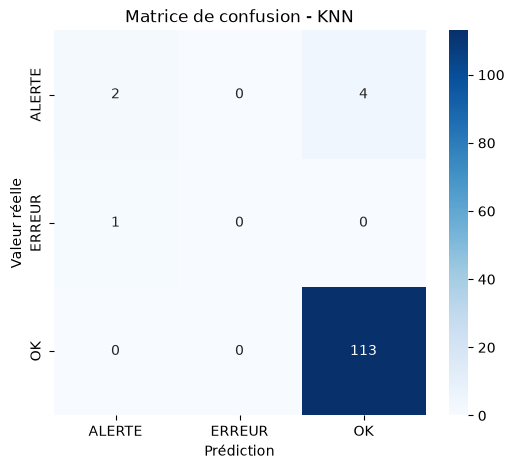

In [159]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=knn.classes_, yticklabels=knn.classes_)
plt.xlabel("Prédiction")
plt.ylabel("Valeur réelle")
plt.title("Matrice de confusion - KNN")
plt.show()

##### 5) Afficher et commenter le rapport de classificaton 

In [160]:
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

      ALERTE       0.67      0.33      0.44         6
      ERREUR       0.00      0.00      0.00         1
          OK       0.97      1.00      0.98       113

    accuracy                           0.96       120
   macro avg       0.54      0.44      0.48       120
weighted avg       0.94      0.96      0.95       120



c:\Users\dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

##### 6) Dans quel cas de problème de classification est-il plus indiqué d’évaluer avec la precision ; même question avec recall; même question avec F1 score; même question avec accuracy

Precision : Quand le coût d'un faux positif est élevé
Recall : Quand le coût d'un faux négatif est élevé
F1-score : Quand tu veux un bon compromis entre precision et recall, notamment sur des classes déséquilibrées, sans privilégier explicitement l'un des deux types d'erreur 
Accuracy : Quand les classes sont équilibrées et que toutes les erreurs ont un coût similaire.